In [15]:
import pandas as pd
import requests
import gzip
from io import BytesIO
import matplotlib.pyplot as plt

# Column names for ISD-Lite format
columns = [
    'year', 'month', 'day', 'hour',
    'temperature',
    'dew_point',
    'sea_level_pressure',
    'wind_direction',
    'wind_speed',
    'sky_condition',
    'precipitation_1h',
    'precipitation_6h',
]

dfs = []
for year in [2023, 2024]:
    url = f"https://www.ncei.noaa.gov/pub/data/noaa/isd-lite/{year}/637400-99999-{year}.gz"
    print(f"Downloading {year}...")
    r = requests.get(url)
    with gzip.open(BytesIO(r.content)) as f:
        df = pd.read_csv(
            f,
            sep=r'\s+',
            names=columns,
            na_values=[-9999]
        )
    dfs.append(df)
    print(f"{year}: {len(df)} rows")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal shape: {df.shape}")
print(df.head(10))

2023: 8288 rows
2024: 6842 rows

Total shape: (15130, 12)
   year  month  day  hour  temperature  dew_point  sea_level_pressure  \
0  2023      1    1     0        155.0      106.0                 NaN   
1  2023      1    1     1        140.0      100.0                 NaN   
2  2023      1    1     2        140.0      100.0                 NaN   
3  2023      1    1     3        142.0      123.0                 NaN   
4  2023      1    1     4        130.0      120.0                 NaN   
5  2023      1    1     5        170.0      140.0                 NaN   
6  2023      1    1     6        186.0      125.0                 NaN   
7  2023      1    1     7        210.0      120.0                 NaN   
8  2023      1    1     8        230.0      120.0                 NaN   
9  2023      1    1     9        231.0      112.0                 NaN   

   wind_direction  wind_speed  sky_condition  precipitation_1h  \
0           360.0        21.0            4.0               NaN   
1     

In [16]:
# Convert tenths to actual units
df['temperature']        = df['temperature'] / 10        # tenths °C → °C
df['dew_point']          = df['dew_point'] / 10          # tenths °C → °C
df['sea_level_pressure'] = df['sea_level_pressure'] / 10 # tenths hPa → hPa
df['wind_speed']         = df['wind_speed'] / 10         # tenths m/s → m/s
df['precipitation_1h']   = df['precipitation_1h'] / 10  # tenths mm → mm

# Build a proper datetime column from year/month/day/hour columns
df['timestamp'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Set timestamp as the index — standard for time series data
df = df.set_index('timestamp')

# Drop the now-redundant columns
df = df.drop(columns=['year', 'month', 'day', 'hour'])

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nSample:")
print(df.head())

Shape: (15130, 8)
Date range: 2023-01-01 00:00:00 → 2024-12-31 16:00:00

Missing values per column:
temperature              13
dew_point                16
sea_level_pressure    15129
wind_direction          986
wind_speed               43
sky_condition         10309
precipitation_1h      15130
precipitation_6h      15098
dtype: int64

Sample:
                     temperature  dew_point  sea_level_pressure  \
timestamp                                                         
2023-01-01 00:00:00         15.5       10.6                 NaN   
2023-01-01 01:00:00         14.0       10.0                 NaN   
2023-01-01 02:00:00         14.0       10.0                 NaN   
2023-01-01 03:00:00         14.2       12.3                 NaN   
2023-01-01 04:00:00         13.0       12.0                 NaN   

                     wind_direction  wind_speed  sky_condition  \
timestamp                                                        
2023-01-01 00:00:00           360.0         2.1     

In [17]:
# Drop columns that are too sparse to be useful
df = df.drop(columns=['sea_level_pressure', 'precipitation_1h', 
                       'precipitation_6h', 'sky_condition'])

# Keep only the useful columns
print("Remaining columns:", list(df.columns))
print(f"Shape after dropping sparse columns: {df.shape}")

# Basic statistics
print("\nBasic statistics:")
print(df.describe().round(2))

Remaining columns: ['temperature', 'dew_point', 'wind_direction', 'wind_speed']
Shape after dropping sparse columns: (15130, 4)

Basic statistics:
       temperature  dew_point  wind_direction  wind_speed
count     15117.00   15114.00        14144.00    15087.00
mean         20.00      13.66          108.01        3.60
std           3.83       2.65           89.49        1.86
min           8.70      -6.00            0.00        0.00
25%          17.00      12.00           50.00        2.10
50%          19.00      14.00           70.00        3.10
75%          23.00      16.00          150.00        4.60
max          31.00      19.40          360.00       25.20


In [18]:
# Find gaps in the hourly data — these represent station downtime
# We expect one reading per hour — anything longer is a gap

df_reset = df.reset_index()  # bring timestamp back as a column

# Calculate time difference between consecutive readings
df_reset['time_diff'] = df_reset['timestamp'].diff()

# A gap is anything longer than 1 hour
gaps = df_reset[df_reset['time_diff'] > pd.Timedelta(hours=1)].copy()

print(f"Total readings: {len(df_reset)}")
print(f"Number of gaps found: {len(gaps)}")
print(f"\nGap summary:")
print(gaps['time_diff'].describe())
print(f"\nLongest gaps:")
print(gaps.nlargest(10, 'time_diff')[['timestamp', 'time_diff']])

Total readings: 15130
Number of gaps found: 751

Gap summary:
count                       751
mean     0 days 04:12:18.215712
std      0 days 12:41:40.138193
min             0 days 02:00:00
25%             0 days 02:00:00
50%             0 days 02:00:00
75%             0 days 03:00:00
max            10 days 00:00:00
Name: time_diff, dtype: object

Longest gaps:
                timestamp        time_diff
8288  2024-01-08 06:00:00 10 days 00:00:00
11941 2024-07-14 17:00:00  5 days 16:00:00
9868  2024-04-01 18:00:00  5 days 01:00:00
14385 2024-11-21 21:00:00  4 days 00:00:00
8315  2024-01-13 07:00:00  3 days 07:00:00
13677 2024-10-14 06:00:00  2 days 19:00:00
8456  2024-01-23 17:00:00  2 days 14:00:00
15098 2024-12-30 06:00:00  1 days 22:00:00
9927  2024-04-07 10:00:00  1 days 18:00:00
12008 2024-07-21 15:00:00  1 days 09:00:00


In [19]:
import numpy as np

# Label each reading with a station status
# We'll look 2 hours BEFORE each gap and mark those readings as "at_risk"
# Everything else is "healthy"
# Readings inside a gap don't exist (station was offline)

df_reset['status'] = 'healthy'

# For each gap, mark the 2 hours before it as "at_risk"
for idx, gap_row in gaps.iterrows():
    gap_start = gap_row['timestamp']
    # The 2 hours before this gap
    at_risk_window = df_reset[
        (df_reset['timestamp'] < gap_start) &
        (df_reset['timestamp'] >= gap_start - pd.Timedelta(hours=2))
    ].index
    df_reset.loc[at_risk_window, 'status'] = 'at_risk'

print("Label distribution:")
print(df_reset['status'].value_counts())
print(f"\nPercentage at_risk: {(df_reset['status']=='at_risk').mean()*100:.1f}%")

Label distribution:
status
healthy    14587
at_risk      543
Name: count, dtype: int64

Percentage at_risk: 3.6%


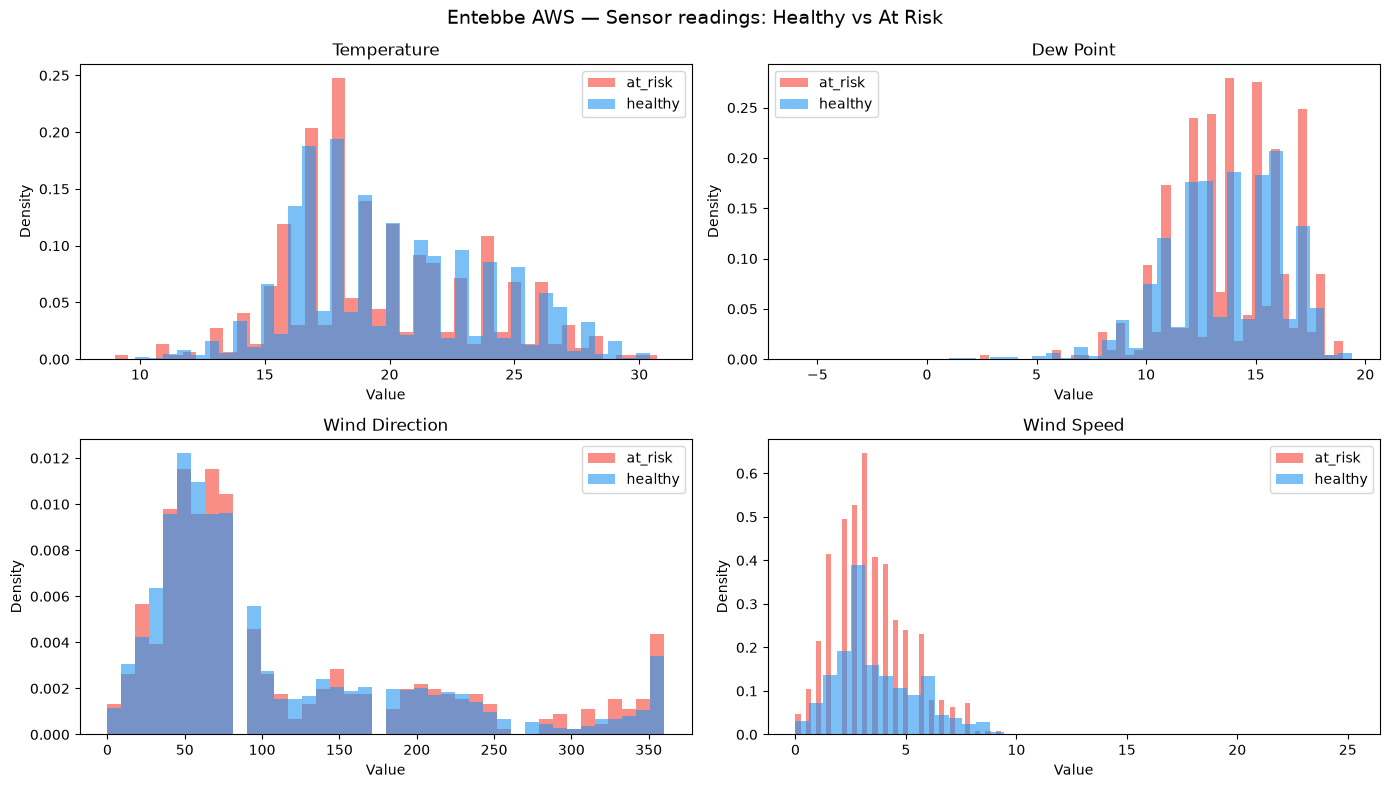

Chart saved to ml/data/eda_distributions.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Entebbe AWS — Sensor readings: Healthy vs At Risk', fontsize=14)

features = ['temperature', 'dew_point', 'wind_direction', 'wind_speed']
colors   = {'healthy': '#2196F3', 'at_risk': '#F44336'}

for ax, feature in zip(axes.flatten(), features):
    for status, group in df_reset.groupby('status'):
        ax.hist(
            group[feature].dropna(),
            bins=40,
            alpha=0.6,
            label=status,
            color=colors[status],
            density=True  # normalize so both are comparable despite different sizes
        )
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('../data/eda_distributions.png', dpi=150)
plt.show()
print("Chart saved to ml/data/eda_distributions.png")

In [21]:
# Create time-based features — these are more powerful than raw values
# We look at the last 3 readings (3 hours) for each row

df_ml = df_reset.copy().set_index('timestamp')

for col in ['temperature', 'dew_point', 'wind_speed']:
    # Rolling mean over last 3 hours
    df_ml[f'{col}_mean_3h'] = df_ml[col].rolling(3).mean()
    # Trend — is it going up or down?
    df_ml[f'{col}_trend_3h'] = df_ml[col].diff(3)

# Hour of day — stations might fail more at night (no solar charging)
df_ml['hour_of_day'] = df_ml.index.hour

# How long since last valid reading (in hours)
df_ml['hours_since_last'] = df_ml.index.to_series().diff().dt.total_seconds() / 3600

print("New features created:")
print(df_ml.columns.tolist())
print(f"\nShape: {df_ml.shape}")
print(df_ml.head())

New features created:
['temperature', 'dew_point', 'wind_direction', 'wind_speed', 'time_diff', 'status', 'temperature_mean_3h', 'temperature_trend_3h', 'dew_point_mean_3h', 'dew_point_trend_3h', 'wind_speed_mean_3h', 'wind_speed_trend_3h', 'hour_of_day', 'hours_since_last']

Shape: (15130, 14)
                     temperature  dew_point  wind_direction  wind_speed  \
timestamp                                                                 
2023-01-01 00:00:00         15.5       10.6           360.0         2.1   
2023-01-01 01:00:00         14.0       10.0           310.0         1.0   
2023-01-01 02:00:00         14.0       10.0            90.0         5.1   
2023-01-01 03:00:00         14.2       12.3            70.0         3.6   
2023-01-01 04:00:00         13.0       12.0            60.0         2.6   

                          time_diff   status  temperature_mean_3h  \
timestamp                                                           
2023-01-01 00:00:00             NaT  hea

In [22]:
# Save the prepared dataset
df_ml.to_csv('../data/entebbe_prepared.csv')
print(f"Dataset saved to ml/data/entebbe_prepared.csv")
print(f"Shape: {df_ml.shape}")
print(f"\nFinal label distribution:")
print(df_ml['status'].value_counts())
print(f"\nFeatures ready for ML:")
feature_cols = [
    'temperature', 'dew_point', 'wind_speed', 'wind_direction',
    'temperature_mean_3h', 'temperature_trend_3h',
    'dew_point_mean_3h', 'dew_point_trend_3h',
    'wind_speed_mean_3h', 'wind_speed_trend_3h',
    'hour_of_day'
]
print(feature_cols)
print(f"\nNext step: train a Random Forest classifier on these features")
print(f"Target column: status (healthy / at_risk)")

Dataset saved to ml/data/entebbe_prepared.csv
Shape: (15130, 14)

Final label distribution:
status
healthy    14587
at_risk      543
Name: count, dtype: int64

Features ready for ML:
['temperature', 'dew_point', 'wind_speed', 'wind_direction', 'temperature_mean_3h', 'temperature_trend_3h', 'dew_point_mean_3h', 'dew_point_trend_3h', 'wind_speed_mean_3h', 'wind_speed_trend_3h', 'hour_of_day']

Next step: train a Random Forest classifier on these features
Target column: status (healthy / at_risk)
